# 04 — Script generation

Produces two figures:

* **Script Equivalence Analysis** + **Model Accuracy Performance**
* **Integrated Script Analysis: Type Distribution and Volume by Model Complexity**

Notebook 03 asked the models to *describe* a sequence. This one asks them to
write a Python program that prints it, and then runs the program.

That difference is the point. A formula has to be read and interpreted before
anyone can say whether it is right. A program does not: it either printed the
sequence or it did not. This is the one place in the benchmark where the
measurement needs no human judgement at all.

**Accuracy** — does the program's output equal the target sequence?

**Equivalence** — do a model's *own* programs print the same thing as each
other? Three programs that print three different sequences mean the model did
not know the sequence.

**No logic lives in this notebook.** Everything comes from `superarc.scripts`.

In [1]:
import pandas as pd
from superarc.notebook import figure

from superarc.scripts import (
    CLASS_LABELS,
    DATASET,
    MODEL_ORDER,
    accuracy_table,
    add_measures,
    classify_script,
    clean_result,
    equivalence_table,
    get_model_display_name,
    load,
    plot_equivalence_and_accuracy,
    plot_integrated,
    process_model_data,
    registered,
    _script_cols,
)
from superarc.registry import B_SCRIPT, RETIRED_COLUMNS, prefix_collisions

pd.set_option("display.width", 170)

df = load()
print(f"{len(df)} sequences x {len(df.columns)} columns")
print(f"{len(MODEL_ORDER)} columns in the figure order, "
      f"{len(registered())} of them registered models")

90 sequences x 81 columns
29 columns in the figure order, 28 of them registered models


## Running the programs

Every program is executed in `superarc.sandbox`, which is pinned to the standard
library. That pin is not caution, it is a measured correction: four o1-Preview
answers are `import sympy; print(list(sympy.primerange(2, 31)))`. The published
run had no sympy installed, so they failed and o1-Preview scored 20.00% at
complexity 2. With sympy present they succeed and it scores 26.67% — the same
answers, a different machine.

The shared namespace the original used is kept, because that is what produced the
published figures. Isolating each program moves ten models by 0.3 to 2.2
percentage points; see `superarc/sandbox.py` for the measurement.

This cell runs about 12,000 programs and takes roughly ten seconds.

In [2]:
df = add_measures(df)
print(f"{len(df.columns)} columns after measuring")

<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?


426 columns after measuring


## The column grammar, and the defect it hid

Columns here are `<model>_script_<i>`, plus a `_result`, `_result_formatted`,
`_accuracy` and `_classification` for each. The obvious way to collect one
model's columns is to test whether the model's name appears in the column name,
and that is what the published accuracy panel did:

```python
model_accuracy_cols = [col for col in accuracy_cols if model.lower() in col.lower()]
```

It is wrong, because **a model name is an atomic keyword, not a substring**.
Four names in this dataset are substrings of a longer model's column name:

In [3]:
rows = []
accuracy_cols = [c for c in df.columns if c.endswith("_accuracy")]
for model in ("mistral", "grok", "qwen", "deepseek"):
    whole = _script_cols(df, model, "_accuracy")
    substring = [c for c in accuracy_cols if model.lower() in c.lower()]
    stolen = sorted(set(substring) - set(whole))
    rows.append({
        "column": model,
        "model": get_model_display_name(model),
        "own columns": len(whole),
        "absorbed by substring": len(stolen),
        "from": ", ".join(sorted({c.split("_script_")[0] for c in stolen})),
    })
pd.DataFrame(rows)

,column,model,own columns,absorbed by substring,from
0,mistral,Mistral,2,6,"mistral-large-3, mistral_large2405"
1,grok,Grok-3,2,5,"grok-3, grok_4.1"
2,qwen,Qwen,2,3,qwen3
3,deepseek,DeepSeek,2,3,deepseek_r1_0525


`startswith` would not have saved it either — the same collision exists at the
prefix level:

In [4]:
prefix_collisions(B_SCRIPT, list(df.columns))

,model,own columns,wrongly absorbed,examples
0,grok,11,27,"grok-3_equivalence_percentage, grok-3_script_1..."
1,mistral,11,32,"mistral-large-3_equivalence_percentage, mistra..."
2,qwen,11,16,"qwen3_equivalence_percentage, qwen3_script_1, ..."
3,deepseek,11,16,"deepseek_r1_0525_equivalence_percentage, deeps..."


The resolver in `superarc.registry` matches **suffix-first, then longest name
wins**. This is the correction behind the accuracy panel below, and it moves
seven values:

| model | complexity | published | corrected |
|---|---|---|---|
| Mistral | 1 | 34.38 | **100.00** |
| Mistral | 2 | 13.12 | **53.33** |
| DeepSeek | 1 | 22.56 | **100.00** |
| DeepSeek | 2 | 11.54 | **58.33** |
| Grok-3 | 1 | 33.33 | **0.00** |
| Grok-3 | 2 | 7.62 | **0.00** |
| Qwen | 2 | 1.28 | **0.00** |

Mistral moves furthest because, in the published run, it was averaged over
sixteen columns instead of two. The table above shows it absorbing six rather
than fourteen, because the second correction on this page removed eight phantom
columns from Mistral-Large-2405 — the two defects are independent, and fixing one
shrank the other. Grok-3 moves *down* to zero, which is what it earns: neither of its two
programs printed a correct sequence.

Note what this implies. The equivalence panel *above* the accuracy panel used the
safe form, and so did the numbers behind Supplementary Figures 5 and 6. So the
two panels of one published figure disagreed with each other about which programs
belong to Grok-3.

## The measures

### Equivalence — do a model's own programs agree?

In [5]:
def by_model(table, value):
    "One row per registered model, in figure order. Retired columns excluded."
    keep = [m for m in registered()]
    pivot = table[table["Model"].isin(keep)].pivot(
        index="Model", columns="Complexity", values=value).reindex(keep)
    pivot.index = [get_model_display_name(m) for m in pivot.index]
    return pivot.round(2)


equiv = equivalence_table(df)
by_model(equiv, "Equivalence %")

Complexity,1,2,3
ChatGPT-4o,100.00,26.67,0.0
ChatGPT-4o-Mini,53.33,20.00,0.0
Gemini-2.5-Pro,53.33,13.33,0.0
Gemini,100.00,10.00,0.0
Claude-3.5,100.00,23.33,0.0
o1-Preview,66.67,3.33,0.0
Mistral,100.00,63.33,0.0
Meta,0.00,0.00,0.0
Cursor-Small,100.00,20.00,0.0
o1-Mini,100.00,16.67,0.0


One column is missing from that table on purpose. This dataset has three Gemini
columns, and the registry declares `gemini` retired: `gemini-thinking` is Gemini
and `gemini-2.5-pro` is Gemini-2.5-Pro. Published Figure 5 excluded `gemini`;
published Figure 6 included it, labelled Gemini-2.5-Pro, and excluded the real
one. Retirement now has to be stated with a reason rather than happening by a
column being missing from a hand-written map:

In [6]:
for column, why in RETIRED_COLUMNS[B_SCRIPT].items():
    print(f"{column}\n  {why}")

gemini
  Superseded original Gemini run. Gemini is represented in this dataset by `gemini-thinking`, and Gemini-2.5-Pro by `gemini-2.5-pro`. Excluded from published Figure 5; Figure 6 included it by mistake under the label Gemini-2.5-Pro.


### Accuracy — did the program print the sequence?

In [7]:
acc = accuracy_table(df)
by_model(acc, "Accuracy")

Complexity,1,2,3
ChatGPT-4o,100.00,55.00,50.00
ChatGPT-4o-Mini,53.33,17.78,0.00
Gemini-2.5-Pro,35.56,11.11,0.00
Gemini,67.78,36.67,33.33
Claude-3.5,100.00,34.44,33.33
o1-Preview,83.33,20.00,0.00
Mistral,100.00,53.33,0.00
Meta,0.00,0.00,0.00
Cursor-Small,100.00,40.00,50.00
o1-Mini,88.89,28.89,33.33


Read down either table: both collapse as complexity rises. Over the 28 registered
models, the means go

| | complexity 1 | 2 | 3 |
|---|---|---|---|
| accuracy | 46.99 | 18.26 | 8.93 |
| equivalence | 46.90 | 10.75 | **0.00** |

Equivalence reaches exactly zero for every one of the 28 at complexity 3 — not one
model produced two agreeing programs. Accuracy does not: seven models still score
above zero there, ChatGPT-4o and Cursor-Small at 50%. So the harder sequences are
not simply beyond reach; what collapses first is *consistency*.

Across the two tables the ordering is not consistent — and where they
disagree sharply, the reason is worth knowing. Grok-4 scores **51.67% accuracy
and 3.33% equivalence** at complexity 1. That looks contradictory until you read
the definition: equivalence compares a model's *runnable* outputs against each
other, so it is 0 whenever fewer than two of them run at all.

In [8]:
cols = _script_cols(df, "grok-3", "_result_formatted")
acc_cols = _script_cols(df, "grok-3", "_accuracy")
low = df[df["Complexity"] == 1]
runnable = low[cols].apply(lambda r: sum(
    pd.notna(v) and "*not found" not in str(v) and "Error" not in str(v) and v != ""
    for v in r), axis=1)

print(f"Grok-4 wrote {len(cols)} programs per sequence, at complexity 1:")
print(f"  rows where fewer than two of them ran:        {(runnable < 2).sum()} of {len(low)}")
print(f"  of those, rows it still got right anyway:     {len(low[(runnable < 2) & low[acc_cols].any(axis=1)])}")
print(f"  accuracy {low[acc_cols].mean().mean() * 100:.2f}%   "
      f"equivalence {low['grok-3_equivalence_percentage'].mean():.2f}%")

Grok-4 wrote 2 programs per sequence, at complexity 1:
  rows where fewer than two of them ran:        29 of 30
  of those, rows it still got right anyway:     29
  accuracy 51.67%   equivalence 3.33%


So equivalence is not a weaker accuracy. It measures consistency *given*
productivity, and a model that writes one working program and one broken one
scores 50% on the first measure and 0% on the second. Both numbers are correct
and they are answering different questions.

## The figure

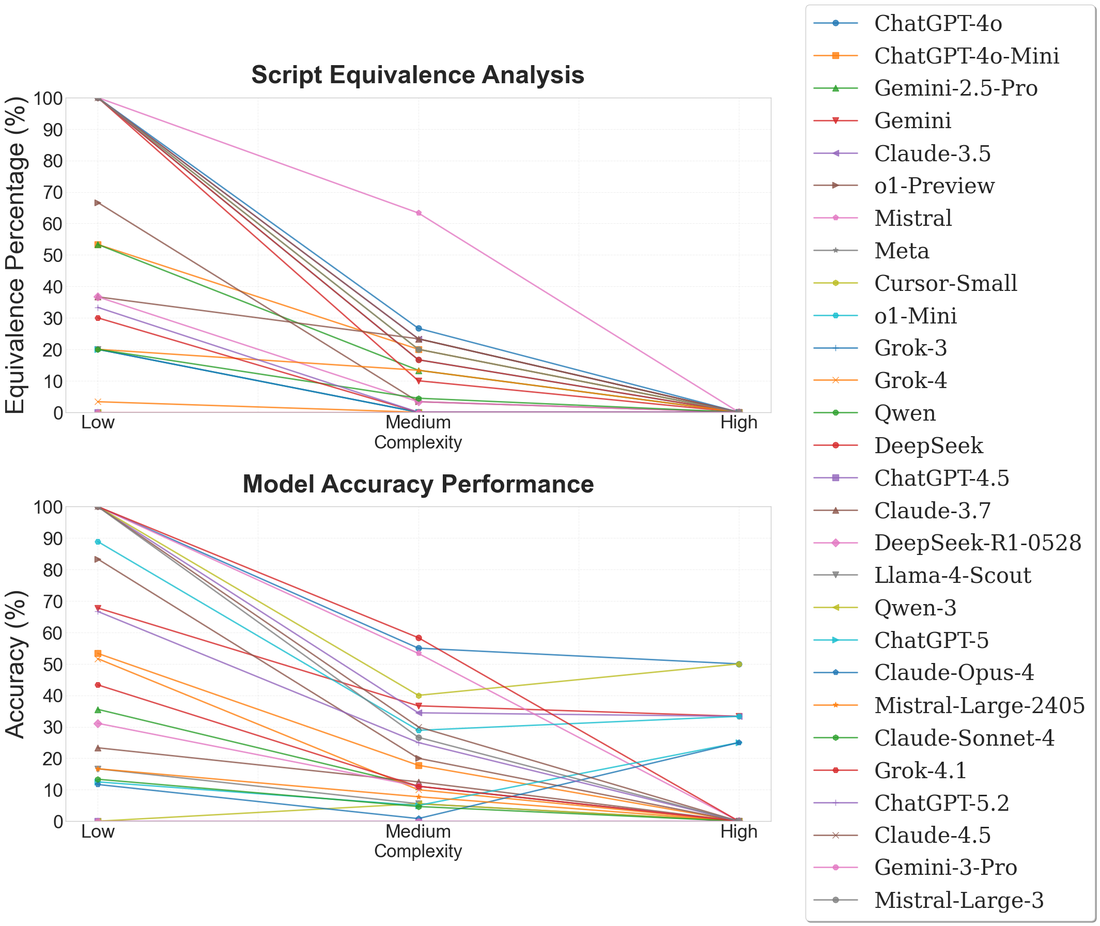

In [9]:
plot_equivalence_and_accuracy(df)
figure("figure04-up.png")

## What kind of programs were they?

Every program is labelled by its text:

| label | meaning |
|---|---|
| **Print** | prints the sequence literally — copying, not modelling |
| **Known sequence** | names a standard object (Fibonacci, primes, Lucas, …) |
| **Pure math** | computes, with operators or a loop |
| **Not found** | nothing usable |

`Print` is the label the benchmark exists to separate from the others: a program
that prints `[1, 1, 2, 3, 5]` scores as accurate while demonstrating no model of
the sequence at all. The classifier is keyword-based, deliberately crude, and
reported as published. Note the precedence — the `Print` test runs first, so
`print('fibonacci')` is Print, not Known sequence.

In [10]:
examples = [
    "print([1, 1, 2, 3, 5])",
    "print('fibonacci')",
    "for n in fibonacci(10): print(n)",
    "for i in range(10): print(i * i)",
    "*not found",
]
pd.DataFrame({"program": examples}).assign(
    classified=lambda d: d["program"].map(classify_script))

,program,classified
0,"print([1, 1, 2, 3, 5])",Print
1,print('fibonacci'),Print
2,for n in fibonacci(10): print(n),Known sequence
3,for i in range(10): print(i * i),Pure math
4,*not found,Not found


In [11]:
volume, total_class, accurate_class = process_model_data(df)

summary = (total_class.pivot_table(index="Model", columns="Classification",
                                   values="Count", aggfunc="sum")[list(CLASS_LABELS)]
           .join(volume.groupby("Model")["Count"].sum().rename("Valid columns")))
summary.index = [get_model_display_name(m) for m in summary.index]
summary.sort_values("Print", ascending=False).head(12)

,Known sequence,Not found,Pure math,Print,Valid columns
Gemini,2,108,70,90,4
ChatGPT-4o,4,38,88,50,4
o1-Mini,3,117,101,49,3
Claude-3.5,5,98,118,49,5
Cursor-Small,4,39,94,43,4
Claude-Opus-4,34,225,71,30,5
DeepSeek,0,67,83,30,3
Grok-3,7,45,98,30,5
ChatGPT-5,30,226,74,30,5
Claude-4.5,0,145,112,13,3


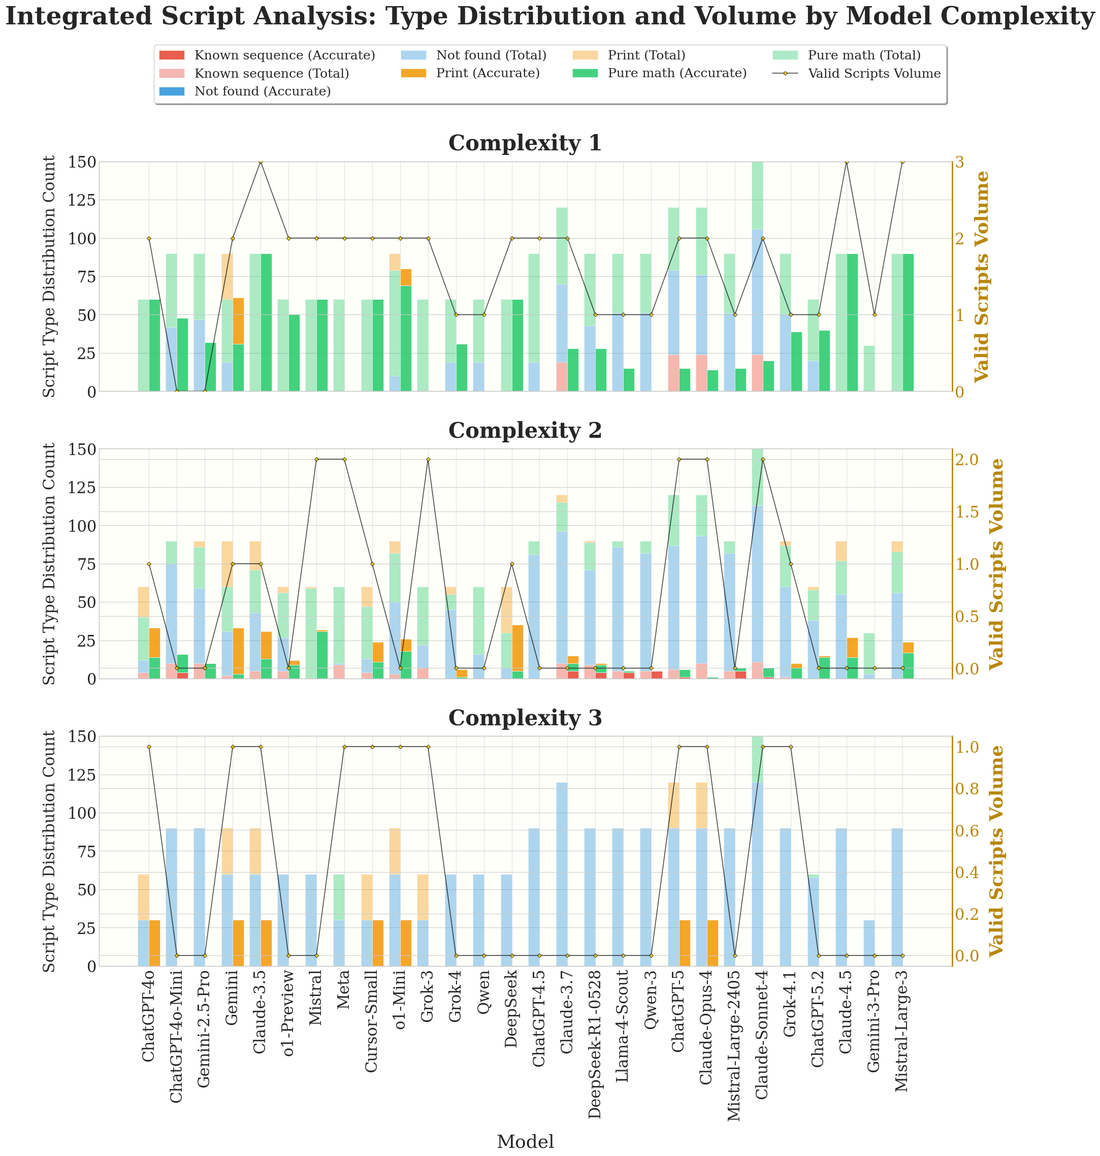

In [12]:
plot_integrated(df)
figure("figure04-bottom.png")

## The correction behind the numbers above

Everything on this page carries one more correction, ruled on by the authors on
2026-09-14. It is the largest of the four this consolidation made, and it is
worth seeing in full because the cause is so small.

### A missing answer was being read as eleven programs

216 cells across 7 models do not hold a list of programs. They hold the quoted
string `"*not found*"` — the model produced nothing at all. The published loader
called `eval` on the cell and then indexed the result **without checking what it
was**, and indexing a *string* gives you characters. So `"*not found*"` became
eleven programs: `*`, `n`, `o`, `t`, ` `, `f`, `o`, `u`, `n`, `d`, `*`. Each was
executed, classified and counted.

Worse, the number of program columns a model gets is the longest value in its
column, so all seven models were given **eleven** program columns where they had
written at most three or four. The cell below reads the raw file the way the
published code did:

In [13]:
import ast

raw = pd.read_csv(DATASET)


def parse_as_published(x):
    if pd.isna(x) or x == "" or x == "*not found":
        return ["*not found"]
    return ast.literal_eval(x)  # no type check -- this is the published reading


rows = []
for column in [c for c in raw.columns if c not in ("sequence", "Complexity")]:
    parsed = raw[column].apply(parse_as_published)
    shredded = parsed.apply(lambda v: isinstance(v, str))
    if shredded.any():
        rows.append({
            "model": get_model_display_name(column),
            "cells with no answer": int(shredded.sum()),
            "of rows": len(parsed),
            "longest real answer": max(len(v) for v in parsed if isinstance(v, list)),
            "columns it created": int(parsed.str.len().max()),
        })
shredding = pd.DataFrame(rows)
shredding

,model,cells with no answer,of rows,longest real answer,columns it created
0,ChatGPT-4o-Mini,61,90,3,11
1,Gemini-2.5-Pro,60,90,3,11
2,Claude-3.7,16,90,4,11
3,DeepSeek-R1-0528,16,90,3,11
4,Llama-4-Scout,21,90,3,11
5,Qwen-3,21,90,3,11
6,Mistral-Large-2405,21,90,3,11


That column count was the **denominator** of those models' accuracy, and it set
the height of their Not-found and Pure-math bars. `*` is a mathematical operator,
so each missing answer also contributed two `Pure math` labels and nine
`Not found` ones:

In [14]:
pd.DataFrame({"character": list('*not found*')}).assign(
    classified=lambda d: d["character"].map(classify_script)
).groupby("classified").size().rename("per missing answer").to_frame()

,per missing answer
classified,
Not found,9
Pure math,2


### And the one count that was typed in by hand

The published script ended with:

```python
# Fix for ChatGPT-4o-Mini at complexity 3
script_data.loc[(script_data['Model'] == 'gpt-4o-mini') &
                (script_data['Complexity'] == 3), 'Count'] = 1
```

a value typed over a computed one. It was patching a symptom of the shredding:
all 30 of that model's complexity-3 cells are `"*not found*"`, and the counting
rule calls a *column* valid when no row in it is missing — which a column of `*`
satisfies. So the code computed 11, somebody wrote 1, and the truth is 0.

With the shredding corrected the computation gives 0 on its own, and the override
is gone. `tests/test_scripts.py::test_no_count_is_set_by_hand` checks that every
count in the figure now equals its computation.

In [15]:
complexity_3 = df[df["Complexity"] == 3]
columns = _script_cols(df, "gpt-4o-mini")
computed = sum(1 for c in columns
               if not complexity_3[c].isna().any()
               and not (complexity_3[c] == "*not found").any())
shown = volume[(volume["Model"] == "gpt-4o-mini")
               & (volume["Complexity"] == 3)]["Count"].iloc[0]
print(f"published: computed 11, typed in 1")
print(f"now:       computed {computed}, shown in the figure {shown}")
print(f"\nChatGPT-4o-Mini now has {len(columns)} program columns; "
      f"at complexity 3 they contain:")
print(sorted(set(complexity_3[columns].to_numpy().ravel())))

published: computed 11, typed in 1
now:       computed 0, shown in the figure 0

ChatGPT-4o-Mini now has 3 program columns; at complexity 3 they contain:
['*not found']


The effect is contained, which is why it was safe to apply. Only the seven
models move, and only their accuracy: a one-character program never produced
runnable output, so it was never in the equivalence numerator or denominator
either.

In [16]:
published_accuracy = {          # complexity 1, as printed
    "gpt-4o-mini": 14.55, "gemini-2.5-pro": 9.70, "deepseek_r1_0525": 8.48,
    "claude-3.7": 8.48, "llama_4_scout": 4.55, "mistral_large2405": 4.55,
    "qwen3": 0.00,
}
now = acc[acc["Complexity"] == 1].set_index("Model")["Accuracy"]
eq_now = equiv[equiv["Complexity"] == 1].set_index("Model")["Equivalence %"]

pd.DataFrame({
    "model": [get_model_display_name(m) for m in published_accuracy],
    "columns now": [len(_script_cols(df, m)) for m in published_accuracy],
    "accuracy published": list(published_accuracy.values()),
    "accuracy now": [round(float(now[m]), 2) for m in published_accuracy],
    "equivalence (unmoved)": [round(float(eq_now[m]), 2) for m in published_accuracy],
}).set_index("model")

,columns now,accuracy published,accuracy now,equivalence (unmoved)
model,,,,
ChatGPT-4o-Mini,3,14.55,53.33,53.33
Gemini-2.5-Pro,3,9.70,35.56,53.33
DeepSeek-R1-0528,3,8.48,31.11,36.67
Claude-3.7,4,8.48,23.33,36.67
Llama-4-Scout,3,4.55,16.67,20.00
Mistral-Large-2405,3,4.55,16.67,20.00
Qwen-3,3,0.00,0.00,0.00


## Verification

`figure04-up` and `figure04-bottom` are both **authorised changes**: they
deliberately no longer match what was printed. Both carry the `"*not found*"`
correction above. The top one also carries the substring column selection; the
bottom one also carries the Gemini column correction — the bar labelled
Gemini-2.5-Pro had been drawn from the `gemini` column, understating its
valid-script volume ninefold.

They are still held to run-to-run determinism, so an unintended change stacked on
top of an authorised one is still caught.

In [17]:
from superarc.parity import check_figures

check_figures(["figure04-up.png", "figure04-bottom.png"])

,figure,status,detail
0,figure04-up.png,changed,Fig 5 script equivalence + accuracy -- CORREC...
1,figure04-bottom.png,changed,Fig 6 integrated script -- CORRECTED: the bar...


In [18]:
import subprocess

dirty = subprocess.run(
    ["git", "status", "--porcelain", "new_plots/", "plots/"],
    capture_output=True, text=True, cwd="..",
).stdout.strip()

print(dirty if dirty else "clean: no published figure was modified")

clean: no published figure was modified


### One thing this does *not* reach

Supplementary Figures 5 and 6 draw the same models' accuracy from
`comparison_models_summary.csv`. The corrections on this page do not propagate to
them, so those two figures disagree with Figure 5 for the seven models above.

That file **is** produced by code, contrary to what this cell said before
2026-09-15: `full_analysis.py` writes it (added 2026-04-06, removed 2026-09-11 as
superseded analysis code, never edited). The earlier "no code produces it" claim
came from a history scan that silently failed and returned nothing for every
pattern, including ones known to be present.

Re-running that producer against the committed file: **21 of 1638 cells differ**
with sympy blocked, 23 with it available, and **0 of 1638** between two runs, so
the drift is real rather than noise. All 21 are in the script case at complexity
2, in Accuracy and Equivalence, and all are higher than published — more generated
programs execute today than executed then.

`superarc/model_summary.py` computes these measures from the data too, but it is
not a drop-in replacement: it disagrees with the committed file on 590 of 1638
cells, mostly because `full_analysis.py` scores accuracy as pass@k per sequence
(did *any* answer work) while this module also carries a per-answer accuracy.
Where the definitions coincide they agree exactly.

**Author's ruling, 2026-09-15 — closer to published wins.** Supplementary Figures
5 and 6 keep reading the committed file. Switching them to the generated summary
would move 590 cells away from print for definitional reasons rather than
corrections.